In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## Test Runs

Estimated value of Pi: 3.144


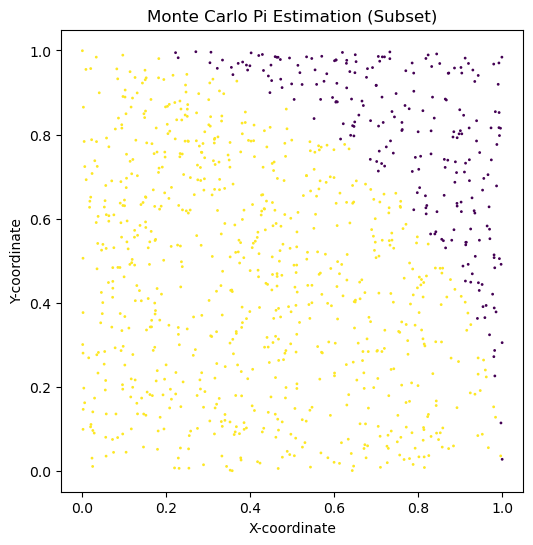

In [ ]:
## Estimating with points (VIBECODED):

import numpy as np
import matplotlib.pyplot as plt

def estimate_pi(num_samples):
    # Generate random x and y coordinates within a 1x1 square
    x = np.random.uniform(0, 1, num_samples)
    y = np.random.uniform(0, 1, num_samples)

    # Calculate the distance from the origin (0,0)
    distance = np.sqrt(x**2 + y**2)

    # Count points that fall within the inscribed quarter circle (distance <= 1)
    points_in_circle = np.sum(distance <= 1)

    # Estimate pi based on the ratio of areas
    pi_estimate = 4 * (points_in_circle / num_samples)
    return pi_estimate, x, y, distance

num_simulations = 100000 # Number of points to scatter
pi_approx, x, y, distance = estimate_pi(num_simulations)
print(f"Estimated value of Pi: {pi_approx}")

# Optional: Visualize a subset of the points
plt.figure(figsize=(6, 6))
plt.scatter(x[:1000], y[:1000], c=distance[:1000] <= 1, cmap='viridis', s=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Monte Carlo Pi Estimation (Subset)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

In [3]:
## Actual Monte Carlo Simulation for paper (initial design)

def pi_para(C, A, m, n):
    return (2*C*n) / (A*m)

def pi_perp(C, A, m, n):
    return (4*C*n) / (A*m)

def para_sim(n_tpicks, trials, mean, C, A):
    trial_list = []
    m_list = []
    for i in range(trials):
        m = np.random.normal(loc=(2*C*n_tpicks)/(A*np.pi))
        m_list.append(m)
        trial_list.append(pi_para(C=C, A=A, m=np.sum(m_list), n=n_tpicks*(i+1)))
    error_list = [100*(np.abs(j-np.pi)/np.pi) for j in trial_list]
    return trial_list, error_list

def perp_sim(n_tpicks, trials, mean, C, A):
    trial_list = []
    m_list = []
    for i in range(trials):
        m = np.random.normal(loc=(2*C*n_tpicks)/(A*np.pi))
        m_list.append(m)
        trial_list.append(pi_perp(C=C, A=A, m=np.sum(m_list), n=n_tpicks*(i+1)))
    error_list = [100*(np.abs(j-np.pi)/np.pi) for j in trial_list]
    return trial_list, error_list

t1, e1 = para_sim(20, 1900, 6, 64, 130)

print(np.mean(t1), np.mean(e1))

## Takes too long to run, too many for-loops. Must vectorize.

3.1577673424124417 0.7076665942675259


## Actual Results

In [3]:
## Vectorized:

def para_sim(n_tpicks, trials, C, A):

    # Vectorize m_list for-loop
    m_list = np.random.normal(loc=(2*C*n_tpicks)/(A*np.pi), size=trials)
    m_cumsum = np.cumsum(m_list)
    # Vectorize taking the trial values and errorrs
    n_array = n_tpicks * np.arange(1, trials + 1)
    trial_array = (2 * C * n_array) / (A * m_cumsum)
    error_array = 100 * np.abs(trial_array - np.pi) / np.pi
    
    return trial_array, error_array

def perp_sim(n_tpicks, trials, C, A):

    # Vectorize m_list for-loop
    m_list = np.random.normal(loc=(4*C*n_tpicks)/(A*np.pi), size=trials)
    m_cumsum = np.cumsum(m_list)

    # Vectorize taknig the trial values and errors
    n_array = n_tpicks * np.arange(1, trials + 1)
    trial_array = (4 * C * n_array) / (A * m_cumsum)
    error_array = 100 * np.abs(trial_array - np.pi) / np.pi
    return trial_array, error_array

In [4]:
n = 100

iter_list = np.arange(500, 500+(500*n), 500)
t1_list = []
t2_list = [] 
e1_list = [] 
e2_list = []

for i in range(n):

    t1, e1 = para_sim(n, iter_list[i], 64, 130)
    t2, e2 = perp_sim(n, iter_list[i], 64, 100)

    t1_list.append(np.mean(t1))
    t2_list.append(np.mean(t2))
    e1_list.append(np.mean(e1))
    e2_list.append(np.mean(e2))

para = np.array([iter_list, t1_list, e1_list])
perp = np.array([iter_list, t2_list, e2_list])

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\David\AppData\Local\Temp\ipykernel_28788\1256663650.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.hlines(y=np.pi, xmin=0, xmax=np.max(para[0]), ls='-', color='black', label='Actual $\pi$')


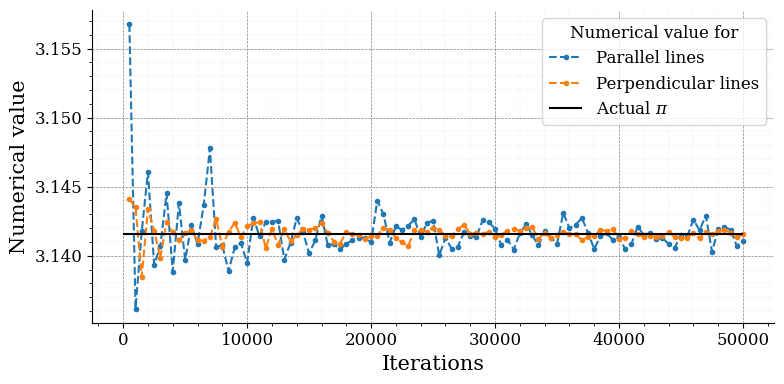

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.size'] = 12

plt.figure(figsize=(8, 4))
plt.plot(para[0], para[1], marker='.', ls='--', label='Parallel lines')
plt.plot(perp[0], perp[1], marker='.', ls='--', label='Perpendicular lines')

plt.hlines(y=np.pi, xmin=0, xmax=np.max(para[0]), ls='-', color='black', label='Actual $\pi$')

plt.xlabel('Iterations', fontsize=15)
plt.ylabel('Numerical value', fontsize=15)

plt.legend(frameon=True, title='Numerical value for')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()

# ax = plt.gca() # Get current axes
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

plt.savefig('Results/Numval_vs_iter.png', format='png', dpi=300)

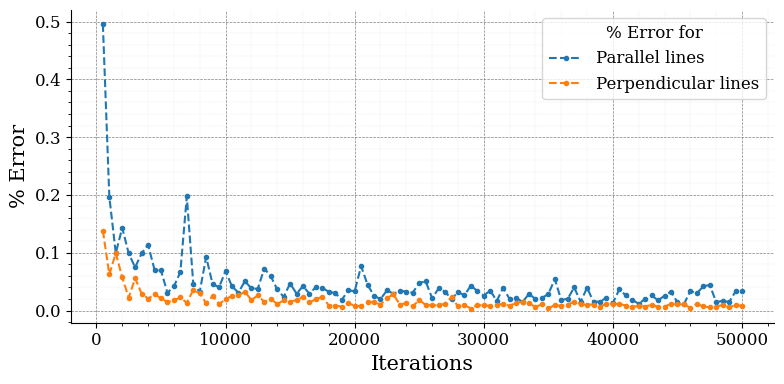

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(para[0], para[2], marker='.', ls='--', label='Parallel lines')
plt.plot(perp[0], perp[2], marker='.', ls='--', label='Perpendicular lines')

plt.xlabel('Iterations', fontsize=15)
plt.ylabel('% Error', fontsize=15)

plt.legend(frameon=True, title='% Error for')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()

ax = plt.gca() # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

plt.savefig('Results/%Error_vs_iter.png', format='png', dpi=300)

## Note to user

The monte-carlo method is inherently stochastic, so do not be surprised by varying results per run. However, the general trend of the error decreasing across iterations is expected across any and all runs.